<a href="https://colab.research.google.com/github/trevorlillywhite/HW5_ST554_Trevor_Lillywhite/blob/main/HW_5_ST_554_Trevor_Lillywhite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5 - ST 554

#### Author: Trevor Lillywhite
#### Due date: March 3, 2026

## Part I: Concepts

### 1) "Five V's of Big Data"

**Instructions:** We discussed the “Five V’s of Big Data”. Give an example of a place where you’ve encountered big
data or a topic you are interested in where big data would arise. Specifically address the five V’s for
the example and whether/how they apply to your example.

**Response:** Concepts for future military operations involve many different networked sensors to understand the environment, the adversary, and the status of friendly forces. This includes satellite/aerial imagery, radar stations, acoustic arrays, fixed and mobile environmental sensors, biometric sensors, and many more. The massive amount of data generated by these sources would certainly be considered "big data," as it clearly meets each of the "Five V's."

+ **Volume:** Each sensor type has the potential to generate massive amounts of data over time, quickly exceeding our ability to handle this data using traditional computation methods. Imagery/video feeds, in particular, will take up an enormous amount of storage space/memory. Even sensors that output simple numerical data streams can quickly scale to unmanageable volumes based on the update frequency and vast number of sensors deployed across the theater of operations.

+ **Variety:** As mentioned earlier, there will be a huge number of different data sources each with distinct data formats. Even sensors belonging to the same family (e.g., acoustic sensors) may have very different output formats depending on the sensor's design, purpose, manufacturer, edge processing capabilities, etc.

+ **Velocity:** Most of these sensors will measure data in real time (or near-real time), though many won't have the ability to continuously stream live data over a network. The velocity of data will vary, but the only "constant" will be change (both in the data available to analysts/decision makers, and in the actual real-world conditions being characterized). This velocity will pose challenges in analyzing the data at the "speed of need" but will further complicate decision making processes if too many changes are shown too fast. Cognitive overload is expected to be problematic, contributing to the "fog of war" from an overabundance of constantly changing data instead of the tradiational lack of data.

+ **Variability:** All sensors have bias and error due to physical sources of noise or technical limitations restricting their capability (e.g., precision, accuracy, resolution, etc.). Sensors fielded in the same area measuring the same thing may output different values due to this noise or even due to changing conditions. Spatiotemporal tagging will be critical to tease out whether data variability is likely due to natural fluctuations or due to changing conditions.   

+ **Value:** There are numerous quotes about the advantage that knowledge has in war. The reason is self evident. Battlefield awareness is critical to ensuring your resources are optimally allocated to defend your strategic postions and gain an advantage over the adversary. Much of the data gathered will have a very low value density, but properly assembled and interpreted, it could save thousands of lives. On the converse, an excess of raw data that has not been transformed to actionable information may be paralyzing.


### 2) CRUD

**Instructions:** Read about the database we’ll use below (part IV). Give an example for each letter in the CRUD acronym in the context of this database.

**Response:**

+ **Create:** When Jeff Knecht created the SQLite version of the database, he had to create new tables corresponding to the MySQL data, and then populate those tables with the corresponding information.
+ **Read:** When Jeff or others want to query the data for browsing or analysis, they need to read what was previously entered into the associated tables, potentially using `JOIN` functions to view related data from multiple tables simultaneously.
+ **Update:** Each year, another season of baseball adds to the wealth of stats that can be added to the database. Jeff hasn't kept up with this recently, but notionally, he could update the database with new rows for the new data generated each year.
+ **Delete:** If an entry is created or updated erroneously (e.g., duplicate rows entered), there's a chance that the data should be deleted instead of simply updated. There may be other situations where an entry should be deleted even if there wasn't a data entry mistake (e.g., if a player is caught using performance enhancing drugs and consequently has their records or special statuses expunged).

### 3) `HAVING` Clause

**Instructions:** What is the purpose of the `HAVING` clause when writing SQL code? (Recall the sqlitetutorial.net tutorial on the `SELECT` statement.)

**Response:** The `HAVING` clause effectively filters the data according the the expression that follows the `HAVING` clause. For example, consider the following query:
```
SELECT col1, col2, AVG(col2) AS avg_col2
FROM table1
GROUP BY group1
HAVING avg_col2 > 10
```
Here, two columns (`col1` and `col2`) are selected from `table1`, along with a new column that calculates the average of col2 after grouping the data by `group1`. However, the groups will only be returned if the value of `avg_col2` is > 10.

The difference between `WHERE` and `HAVING` is that `WHERE` filters the raw data, while `HAVING` filters the grouped/aggregated data.



## Part II: Simulation of a Sampling Distribution

### 4) Sampling Distribution of SLR Model Sample Slope

**Instructions:** We looked at using simulation to investigate the sampling distribution of $\hat{p}$ in the notes. We'll now look at the sampling distribution of the sample slope from an SLR model using simulation.

+ Recall we assume the following model for SLR:
$Y_i = β_0 + β_1x_i + E_i$
where the $E_i$ are assumed to be indendent and identically distributed from a Normal distribution
with mean 0 and variance $σ^2$. Let's assume $σ^2 = 1$ for simplicity.
+ We can generate data from this model by assuming values for $β_0$, $β_1$, and $n$, along with a sequence of $x$ values via the following code:
>[`code omitted here for brevity`]
+ Now we can use `sklearn` to obtain the estimate for the slope (and save that value) as we did earlier in the course.
+ Repeat the above process 5000 times. To be specific
    - Generate the y values using the code with `rng.standard_normal()`
    - Find the 'best' slope via `sklearn`
    - Save that slope in some object

_Approach:_ We will first replicate the code shown in the assignment instructions to verify its functionality. After we have our sample data, we will verify functionality of our `sklearn` regression. We will then turn that code into a function that returns the simulated data points including randomized noise (fixed by a random seed for repeatability). Then we will use `sklearn` to regress the 'best' slope for each simulation in a specified sample size (here, 5000). Finally, we can use that object with the returned set of sample slopes for further analysis.

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.  0.  1.  2.  3.  4.  5.  6.
  7.  8.  9. 10.  0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


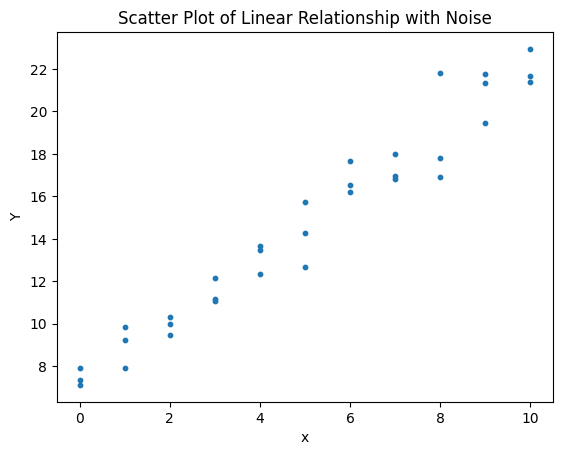

In [1]:
# Replicate code to determine one sample of data points

#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
print(x)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y, s=10)
plt.title('Scatter Plot of Linear Relationship with Noise')
plt.xlabel('x')
plt.ylabel('Y')
plt.show()

In [2]:
# Check shape of x, y
print(x.shape)
print(y.shape)

(33,)
(33,)


In [3]:
# Determine sample slope using sklearn
# Import relevant module
import sklearn
# Instantiate linear regression model as an object
lin_reg = sklearn.linear_model.LinearRegression()
# Fit model on data
lin_reg.fit(x.reshape(-1,1), y.reshape(-1,1))
# Determine fitted parameters (coefficient (AKA slope) and intercept)
slope = lin_reg.coef_
intercept = lin_reg.intercept_
print('Fitted Slope: ', slope[0,0].round(4))
print('Fitted Intercept: ', intercept[0].round(4))

Fitted Slope:  1.4745
Fitted Intercept:  7.259


The fitted slope and intercept are very close to the true values (1.5 and 7).

Now that we have demonstrated the ability to calculate the slope once, we will turn this into a function.

In [4]:
# Wrap code into a function to return a set of sample slopes

def get_slopes(n_samples, beta_0_input = 7, beta_1_input = 1.5):
    '''
    This function takes given value of beta_0 (default: 7) and
    beta_1 (default: 1.5) and generates random samples around the line
    Y_i = beta_0 + beta_1*x_i + E_i where E_i is determined by
    randomly sampling a unit standard normal distribution.
    The user specifies the number of samples to repeat.
    The function outputs an array of the sample slopes for each sample.
    '''
    # Set random seed
    seed = 32
    rng = default_rng(seed)
    # Get three 'values' of x at each integer from 0 to 10.
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
    n = len(x)

    # Initialize empty array for each sample's fitted slope
    slope_set = np.zeros(n_samples)
    # Iteratively create y-values for each sample and fit a slope using SLR
    for i in range(n_samples):
        # Create the 'responses' modeled from the line plus a random deviation
        y = beta_0 + beta_1*x + rng.standard_normal(n)
        # Instantiate linear regression model as an object
        reg = sklearn.linear_model.LinearRegression()
        # Fit model on data
        reg.fit(x.reshape(-1,1), y.reshape(-1,1))
        # Determine fitted slope (the first and only SLR coefficient)
        slope_set[i] = reg.coef_[0,0]
    return slope_set

In [5]:
# Generate 5000 independent sample slopes
slopes = get_slopes(5000)
# Print mean to check functionality
slopes.mean()

np.float64(1.5001065405182452)

**Instructions:**
+ We can use the many values of the sample slope as an approximation to the sampling distribution of the sample slope! Create a histogram of the sample slope values you found.

_Approach:_ We will convert the `numpy` array to a pandas series. Then, we can use the built-in histogram function quite conveniently.

In [6]:
# Import relevant module
import pandas as pd
# Convert results to pandas DataFrame
slopes = pd.DataFrame(slopes)
slopes.columns = ['fitted_slope']
slopes

,fitted_slope
0,1.474506
1,1.452806
2,1.533154
3,1.472032
4,1.441669
...,...
4995,1.470190
4996,1.461474
4997,1.461199
4998,1.502327


Text(0, 0.5, 'Frequency')

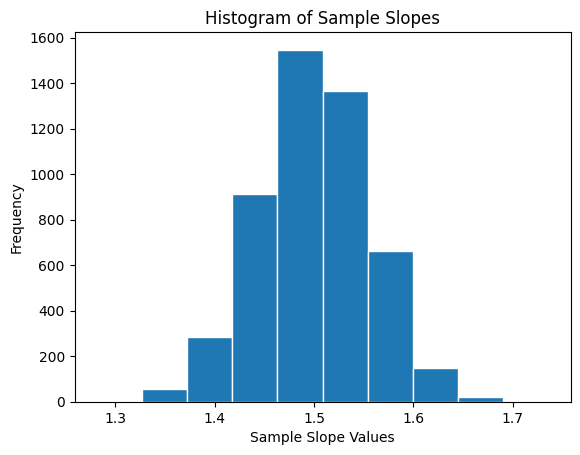

In [7]:
# Create histogram
slopes.hist(edgecolor='white', grid=False)
plt.title('Histogram of Sample Slopes')
plt.xlabel('Sample Slope Values')
plt.ylabel('Frequency')

The histogram shows an approximately normal distribution, as expected, with a sample mean somewhere around 1.5.

**Instructions:**
+ Use your sampling distribution to approximate the probability of observing a sample slope larger than 1.65. This can be done by looking at the proportion of simulated values larger than 1.65.

_Approach:_ First, we will use the `describe()` method with custom quantile selections to gain numerical insights about the sample distribution. Then, we will subset the data and measure the length of the new DataFrame with sample slopes larger than 1.65. This length will be dividied by the total number of samples (5000) to determine the proportion of simulated slopes larger than 1.65. Finally, we will compare this result with the insights we previously gained using the `describe()` method to validate the reasonability of our results.

In [8]:
# Describe dataset using relevant percentiles
pct = [0.9, 0.95, 0.99, 0.999]
slopes.describe(percentiles=pct)

,fitted_slope
count,5000.000000
mean,1.500107
std,0.055322
min,1.281509
50%,1.500038
90%,1.570923
95%,1.590980
99%,1.626417
99.9%,1.679030
max,1.735569


Based on these results, we should expect our calculated proportion to be somewhere between the 99th and 99.9th percentiles. The subsetted DataFrame should include between 5 and 50 samples.

In [9]:
slopes_high = slopes[slopes.fitted_slope > 1.65]
slopes_high.describe()

,fitted_slope
count,19.000000
mean,1.672616
std,0.023501
min,1.650052
25%,1.656088
50%,1.665444
75%,1.682093
max,1.735569


There are 19 fitted slopes with values > 1.65. The numeric sumamries confirm that only the desired slopes were included in the subsetted DataFrame.

In [10]:
# Determine proportion of slopes with values > 1.65
proportion = len(slopes_high)/len(slopes)
print('Proportion of sample slopes > 1.65 (decimal): ', proportion)

Proportion of sample slopes > 1.65 (decimal):  0.0038


The probability of observing a sample slope > 1.65 is approximately 0.0038.

This value aligns with our initial bounding analysis. The number of sample slopes in the range of interest was 19 (predicted to be between 5 and 50), and the percentile corresponding to a sample slope of 1.65 is between 99% and 99.9% (because the actual proportion is 0.0038, or 0.38%, which corresponds to the top 99.62% of the sample set).

**Instructions:**
+ Give an interpretation of this value and why it might be important for us in relation to a hypothesis test.

**Response:** If the simulation was repeated an extremely large number of times, we would expect that approximately 0.38% of the sample slopes would be above a value of 1.65. There is some error in this value because the statistic was estimated from a finite sample size.

In hypothesis testing, we would set a null hypothesis and an alternative hypothesis. If we set a null hypothesis that the true slope is 1.5 and an alternative hypothesis that the true slope is greater than 1.5, we would need to conduct a number of tests to determine if we have enough statistical evidence to reject the null hypothesis. Let's say the alternative hypothesis is that the true slope is 1.65. The simulations performed above show that, if the null hypothesis is true, we would only reach a value of > 1.65 a very small proportion of the time. As long as our alpha value (Type I Error, or false positive probability) is > 1%, we would be able to clearly distinguish a mean sample slope of 1.65 from the null hypothesis. With an alpha value of 0.05 (which is a common selection), the mean sample slope would only be within the one-sided 95% confidence interval of the null hypothesis if it was below 1.59. Any greater value would lead to a rejection of the null hypothesis in favor of the alternative hypothesis.

## Part III: Big Data Examples & Rare Events

### 5) Bias in ML Models

**Instructions:**
Consider this article about bias in machine learning models: https://international-review.icrc.org/articles/biases-machine-learning-big-data-analytics-ihl-implications-913
+ Pick an example in the article and briefly outline the issue around the data used to fit the model.

**Response:** The article mentioned an example of implicit bias where an automated resume screening system used by Amazon was shown to disfavorably rank women whose resumes indicated their presumed gender (e.g., "women's chess club captain"). This resulted from training data that used gender-specific language and drew a link between women and a lower hiring favorability. The precise details leading to the bias are unclear from the article, but it is possible that the model identified a spurrious correlation or even that it uncovered human bias that was actually present in tradiational hiring activities. Regardless, the bias was carried forward and likely negatively (and unjustly) impacted applicants before it was discovered.  

**Instructions:**
+ Describe how we might augment the data or otherwise account for the bias in that situation.

**Response:** The model should be checked for biases during initial training and fine tuning, and even after deployment (especially if the model is not static, such as if it adapts over time through reinforcement learning or is periodically augmented with newer training data). Once a bias is uncovered, the developers should investigate the cause to see if it can be remediated. There are several options to prevent or correct biases, as long as they are discovered and adequately characterized.

+ If the full dataset contained a balanced/representative population, but the model still produced a bias, the development team can check to see if the training and validation/test sets were properly split (e.g., were randomization and stratification properly applied?).
+ If portions of a population weren't adequately represented but data is available, more data can be mixed into the training (and validation/test) set. For Amazon, they could search for additional resumes that weren't included or seek resume sources from similar companies.
+ If sufficient data is not available to represent some portions of a population, data for the over-reprsented portion can be intentionally under-sampled to restore balance, if the overall dataset is big enough. Otherwise, synthetic data for under-represented portions of the population can be made (if practical) through techniques like Synthetic Minority Oversampling Technique (SMOTE). It would be difficult to generate entirely new synthetic resumes in this case, but other successful resumes could be modified to create examples where the implied gender is neutrally or positively favored (to counter-balance the model's internal parameters).
+ Specific to this case, since the cause of the bias can be identified, another data processing layer can be added to neutralize bias-inducing language before the resume is analyzed by the biased model. For example, an LLM can remove or modify words hinting at a person's gender or race (though this would require oversight to ensure additional biases are not being added). If this technique is used, the pre-processing algorithm should be widely tested, potentially on the entire training/test set before analytical model development.

### 6) Big Data Usage in Earth Sciences

**Instructions:**
Consider this article about big data usage in the Earth Sciences: https://www.science.org/doi/10.1126/science.adh9607
+ Choose one of the three major areas the paper discusses. Summarize the use of big data there. Are there any biases or other missing data that might affect results? (I know this is likely difficult as most of us aren’t experts in Earth science - just do your best - my goal is to try to get us to always ask questions about the data collected and used for a study!)

**Response:** The section "A Three-Dimensional Ocean" describes the large increase in oceanic data collected across the ocean surface and at depth over the past few decades. Data is currently collected and reported, sometimes in real-time, using thousands of autonomous sensor-laden buoys, surface vehicles, and underwater vehicles. Although the article did not name the primary parameters they measure, it likely includes temperature, pressure, salinity, dissolved gases (e.g., oxygen, nitrogen, carbon dioxide), and potentially clarity and flow.

Figure 2 powerfully shows the large increase in sensor measurement density across the ocean. While only a few linear tracks were monitored in the open ocean (far from land) in 1995, a very large portion of the ocean is being monitored now. However, this two-dimensional chart does not differentiate between surface, near-surface, and deep ocean readings. Due to the relative ease of collecting and communicating information at the surface (or near surface) and much greater complexity of collecting and measuring at depth, it is very likely that much of the world's ocean remains uncharacterized below easily accessible areas. Though the surface interactions with the sun and atmosphere greatly affect ocean properties, there are undoubtedly large driving forces deep down that we do not yet understand. The figure also does not show what properties have been measured in various locations. There may be important properties that are only routinely measured in some parts of the globe (e.g., near shore and along shipping routes) while autonomous vehicles/sensors remain unable to process those measurements autonomously due to technological or cost constraints. It would be very interesting to see more iterations of the map filtered by different depths and measurement types.

### 7) Rare Events

**Instructions:**
Read through this short article: https://allendowney.substack.com/p/superbolts?utm_source=substack&utm_medium=email
+ Mostly I just want you to read this article to understand some ways in which rare events, and statisticians, play a role in different places. To have something to put here, can you think of another variable or scenario where understanding rare events is important?

**Response:** In particle physics, things often do not behave intuitively. Not only is it hard to predict behaviors before seeing them, it's hard to even see them because of the extremely small spatial, temporal, and potentially energy scales of the events. Sometimes, a huge amount of observation has to occur to see very small, very brief phenomena, such as the decay of a long-lived nuclide or subatomic particle. Because we cannot "see" these events in the traditional sense, we have to rely on highly sophisticated measurements, intricately designed to gather data to match a theory. But who's to say that a given observation is actually due to the event we think it's from? There's alway the potential for some other unknown or unforseen interaction to give a false impression that a theory was confirmed (or disproving evidence was gathered). These experimental physicists need to understand the statistics of rare events and critically assess the experimental design to identify other factors that can cause confounding signals that can invalidate results and associated interpretations.

(As a second fun example, consider random bit flipping events from radiation interacting with single atoms in digital memory - these can be a pain and must be guarded against, especially in high consequence or high radiation environments!)

## Part IV: Querying a Database

**Instructions:** There is a database file on the assignment link called Lahman.db that is an sqlite database downloaded from here. This database has information on Major League Baseball.

https://github.com/jknecht/baseball-archive-sqlite

### 8) View Table List
**Instructions:** Connect to the database (probably by uploading to Colab) and then look at all of the tables in the database (use `read_sql()` from pandas to have this returned as a data frame).

_Approach:_ We will import the `sqlite3` module and connect to it using SQL. After we practice our SQL skills to look at all of the tables in the database, we will use `pandas` to repeat the process and view the results more cleanly in a DataFrame.

In [11]:
# Import relevant module
import sqlite3
# Connect to the .sqlite file (uploaded to the Colab session)
con = sqlite3.connect("lahman_1871-2022.sqlite")

In [12]:
# create cursor object
cursor = con.cursor()
# Return table schema via SQL query
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''
# Execute query
cursor.execute(get_schema)
# Return result
result = cursor.fetchall()
# Close connection
cursor.close()
# Print Results
for i in result:
    print(i)

('table', 'AllstarFull', 'AllstarFull', 2, 'CREATE TABLE AllstarFull (\nplayerID TEXT,\nyearID INTEGER,\ngameNum INTEGER,\ngameID TEXT,\nteamID TEXT,\nlgID TEXT,\nGP INTEGER,\nstartingPos TEXT\n)')
('table', 'Appearances', 'Appearances', 3, 'CREATE TABLE Appearances (\nyearID INTEGER,\nteamID TEXT,\nlgID TEXT,\nplayerID TEXT,\nG_all INTEGER,\nGS INTEGER,\nG_batting INTEGER,\nG_defense INTEGER,\nG_p INTEGER,\nG_c INTEGER,\nG_1b INTEGER,\nG_2b INTEGER,\nG_3b INTEGER,\nG_ss INTEGER,\nG_lf INTEGER,\nG_cf INTEGER,\nG_rf INTEGER,\nG_of INTEGER,\nG_dh INTEGER,\nG_ph INTEGER,\nG_pr INTEGER\n)')
('table', 'AwardsManagers', 'AwardsManagers', 4, 'CREATE TABLE AwardsManagers (\nplayerID TEXT,\nawardID TEXT,\nyearID INTEGER,\nlgID TEXT,\ntie TEXT,\nnotes TEXT\n)')
('table', 'AwardsPlayers', 'AwardsPlayers', 5, 'CREATE TABLE AwardsPlayers (\nplayerID TEXT,\nawardID TEXT,\nyearID INTEGER,\nlgID TEXT,\ntie TEXT,\nnotes TEXT\n)')
('table', 'AwardsShareManagers', 'AwardsShareManagers', 6, 'CREATE TABLE 

Using the SQL query above, we discovered about 27 tables in the database.

Now we will practice database queries using `pandas`, which will allow us to view the results more clearly.

In [13]:
schema_df = pd.read_sql(get_schema, con)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


That's better! Now we can cleanly view the table schema in a well-formatted table. By directly retrieving the table schema using `pandas`, we also were automatically provided with the correct column headers.

### 9) Teams that played in 2015
**Instructions:** Write an SQL query using `pd.read_sql()` that returns all the teams that played in the year 2015 with all of the corresponding columns from the `Teams` table.

_Approach:_ We will use the `pd.read_sql()` method to query the `Teams` table, using `WHERE` to filter the teams who played in 2015.

To determine the column to apply the filter to, we will first query the entire `Teams` table with a couple example results.

In [14]:
# Define query
query_teams = '''
        SELECT *
        FROM Teams
        LIMIT 3
        '''
# Generate DataFrame for Teams table
teams = pd.read_sql(query_teams, con)
teams

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,1871,NA,BS1,BNA,None,3,31,None,20,10,...,24,0.834,Boston Red Stockings,South End Grounds I,None,103,98,BOS,BS1,BS1
1,1871,NA,CH1,CNA,None,2,28,None,19,9,...,16,0.829,Chicago White Stockings,Union Base-Ball Grounds,None,104,102,CHI,CH1,CH1
2,1871,NA,CL1,CFC,None,8,29,None,10,19,...,15,0.818,Cleveland Forest Citys,National Association Grounds,None,96,100,CLE,CL1,CL1


Here, we see that there is a `yearID` column. We will attempt filtering the year using that column.

In [15]:
# Define query
query_teams_2015 = '''
        SELECT *
        FROM Teams
        WHERE yearID = 2015
        '''
# Generate DataFrame for Teams table filtered by year
teams_2015 = pd.read_sql(query_teams_2015, con)
teams_2015

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


These results look credible. There is a realistic number of teams for a given year (30) and none of the team names look outdated (to a casual sports observer). All 48 columns were returned.

### 10) Hall of Fame Players
**Instructions:** Write an SQL query using `pd.read_sql()` that returns all of the players in the hall of fame, the year they were voted into the hall of fame, and their category - see the `HallOfFame` table, the inducted variable is important here.

_Approach:_ Again, we will start by looking at a couple example rows for the entire `HallOfFame` table. That will guide us to the correct column names for the requested data subset.

In [16]:
# Define query
query_HOF = '''
        SELECT *
        FROM HallOfFame
        LIMIT 3
        '''
# Generate DataFrame for HallOfFame table
HOF = pd.read_sql(query_HOF, con)
HOF

,playerID,yearid,votedBy,ballots,needed,votes,inducted,category,needed_note
0,aaronha01,1982,BBWAA,415,312,406,Y,Player,None
1,abbotji01,2005,BBWAA,516,387,13,N,Player,None
2,abreubo01,2020,BBWAA,397,298,22,N,Player,None


Aha! The hint in the instructions makes sense now. We need to filter the results using the WHERE clause to only include rows where the individual was actually inducted (`inducted` = Y). We will keep the `playerID`, `yearID`, and `category` columns.

In [17]:
# Define query
query_HOF_inducted = '''
        SELECT playerID, yearID, category
        FROM HallOfFame
        WHERE inducted = 'Y'
        '''
# Generate DataFrame for HallOfFame table with desired info on actual inductees
HOF_inducted = pd.read_sql(query_HOF_inducted, con)
HOF_inducted

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


There were 340 inductees across the years and across various categories. If needed, the `playerID` column could be used to join these entries with the `People` table to exchange the `playerID` column for their actual names.

### 11) Pittsburgh Pirates Managers
**Instructions:** Write an SQL query using `pd.read_sql()` that return all unique managers of the Pittsburgh Pirates (`teamID` of `PIT`) and only that information from the `Managers` table. Hint: Check out `SELECT
DISTINCT`

_Approach:_ Following the same approach, we will look at a couple examples from the full `Managers` table and then choose the columns we are interested in. We will use SELECT DISTINCT so we don't get duplicate values for managers who were there for multiple seasons.

In [18]:
# Define query
query_mgr = '''
        SELECT *
        FROM Managers
        LIMIT 3
        '''
# Generate DataFrame for HallOfFame table
mgr = pd.read_sql(query_mgr, con)
mgr

,playerID,yearID,teamID,lgID,inseason,G,W,L,rank,plyrMgr
0,wrighha01,1871,BS1,NA,1,31,20,10,3,Y
1,woodji01,1871,CH1,NA,1,28,19,9,2,Y
2,paborch01,1871,CL1,NA,1,29,10,19,8,Y


Using these columns, we know that we will need to filter by `teamID`.

In [19]:
# Define query
query_mgr_unique = '''
        SELECT DISTINCT playerID
        FROM Managers
        WHERE teamID = 'PIT'
        '''
# Generate DataFrame for HallOfFame table
mgr_unique = pd.read_sql(query_mgr_unique, con)
mgr_unique

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


There have only been 41 distinct managers for the Pittsburgh Pirates. If we wanted to include the other rows of the table, we would use a GROUP BY clause, but it would be difficult to aggregate many of the other rows.

### 12) Hall of Fame Managers
**Instructions:** Use SQL code and the `HallOfFame` and `Managers` tables to return all of the `playerIDs` for the people that managed for a team that were inducted into the hall of fame. Also, programmatically report the number of such people - this can be done in `pandas` after returning the data from the call to `pd.read_sql()`.

_Approach:_ We have already dealt with the `HallOfFame` and `Managers` tables, so we know what columns to expect. Each table has a `playerID` column that can be used as a key for a table `JOIN`. We also need to be cautious not to rely on the `category` column from the `Hall of Fame` table because it only indicates what category they were inducted into -- the instructions also want us to identify people who could have been inducted into a different category but were a manager at some point in time.

If a person was inducted into the Hall of Fame and is included in the Managers table, they need to be in our results. Therefore, we will do an `INNER JOIN` function.

In [20]:
# Define query
query_HOF_inducted_mgr = '''
        SELECT DISTINCT Managers.playerID
        FROM Managers
        INNER JOIN HallOfFame ON Managers.playerID = HallOfFame.playerID
        WHERE HallOfFame.inducted = 'Y'
        '''
# Generate DataFrame for HallOfFame table with desired info on actual inductees
HOF_inducted_mgr = pd.read_sql(query_HOF_inducted_mgr, con)
HOF_inducted_mgr

,playerID
0,alstowa01
1,andersp01
2,ansonca01
3,applilu01
4,baineha01
...,...
92,willidi02
93,willite01
94,wrighge01
95,wrighha01


There were 97 people who were a team manager at some point in time and also inducted into the Hall of Fame for any category. This is shown automatically at the bottom of the returned DataFrame. However, we will confirm by explicitly asking for the DataFrame length.

In [21]:
len(HOF_inducted_mgr)

97

Confirmed - 97 individuals.

### 13) Season Records for Hall of Fame Managers
**Instructions:** Now use the same two tables (`HallOfFame` and `Managers`) and an SQL query to return every season managed by each manager that made it to the hall of fame (so do this with an SQL join, not via `pd.merge()`). You should return the `playerID` (manager ID), `G`, `W`, and `L` columns from the `Managers` table.

_Approach:_ Since we now want to know about each season's stats for each manager in the previous table, we no longer should use `SELECT DISTINCT`. This will also open us up to more easily including more columns. We can merge the same tables using an `INNER JOIN` but specify more columns to return.

In [22]:
# Define query
query_HOF_inducted_mgr_seasons = '''
        SELECT Managers.playerID, Managers.G, Managers.W, Managers.L
        FROM Managers
        INNER JOIN HallOfFame ON Managers.playerID = HallOfFame.playerID
        WHERE HallOfFame.inducted = 'Y'
        '''
# Generate DataFrame for HallOfFame table with desired info on actual inductees
HOF_inducted_mgr_seasons = pd.read_sql(query_HOF_inducted_mgr_seasons, con)
HOF_inducted_mgr_seasons

,playerID,G,W,L
0,alstowa01,154,92,62
1,alstowa01,154,98,55
2,alstowa01,154,93,61
3,alstowa01,154,84,70
4,alstowa01,154,71,83
...,...,...,...,...
991,wrighha01,46,22,23
992,wrighha01,138,68,69
993,wrighha01,155,87,66
994,wrighha01,133,72,57


This table looks reasonable. The total number of games per season is credible, and the table length is roughly 10 times as long, indicating an average managing period of 10 years. Some seasons had very few games, likely due to the manager joining or leaving part-way through the season.

**Instructions:** Second, determine the overall win/loss records (sum of wins and sum of losses) for each of these hall of fame managers.

_Approach:_ The previous table has the raw data we need, but the statistics need to be aggregated for each player. We can use the same query but using the GROUP BY clause and a SUM aggregation function. We won't aggregate the total games played (`G`) because it was not requested.

In [23]:
# Define query
query_HOF_inducted_mgr_agg = '''
        SELECT Managers.playerID, SUM(Managers.W), SUM(Managers.L)
        FROM Managers
        INNER JOIN HallOfFame ON Managers.playerID = HallOfFame.playerID
        WHERE HallOfFame.inducted = 'Y'
        GROUP BY Managers.playerID
        '''
# Generate DataFrame for HallOfFame table with desired info on actual inductees
HOF_inducted_mgr_agg = pd.read_sql(query_HOF_inducted_mgr_agg, con)
HOF_inducted_mgr_agg

,playerID,SUM(Managers.W),SUM(Managers.L)
0,alstowa01,2040,1613
1,andersp01,2194,1834
2,ansonca01,1296,947
3,applilu01,10,30
4,baineha01,1,3
...,...,...,...
92,willidi02,1571,1451
93,willite01,273,364
94,wrighge01,59,25
95,wrighha01,1225,885


The function appears to have worked. There are 97 rows, which matches our previous conclusion that 97 people who were a team manager at some point in time were also inducted into the Hall of Fame for any category.

**Instructions:** Third, create a new variable that is the win/loss percentage (`W`/(`W`+`L`)). Lastly, sort the resulting data by the win/loss percentage variable (from largest to smallest). The last three parts can be done in pandas with the returned data or you can do it via SQL in your call to `pd.read_sql()`.

_Approach:_ We will use the SQL query method by revising the previous query to include a new column with the custom aggregation function and the ORDER BY clause (descending with DESC). The aggregation function will start with "1.0*..." to avoid integer division.

In [24]:
# Define query
query_HOF_inducted_mgr_agg = '''
        SELECT Managers.playerID, 1.0*SUM(Managers.W)/(SUM(Managers.W)+SUM(Managers.L)) AS 'W_ratio'
        FROM Managers
        INNER JOIN HallOfFame ON Managers.playerID = HallOfFame.playerID
        WHERE HallOfFame.inducted = 'Y'
        GROUP BY Managers.playerID
        ORDER BY W_ratio DESC
        '''
# Generate DataFrame for HallOfFame table with desired info on actual inductees
HOF_inducted_mgr_agg = pd.read_sql(query_HOF_inducted_mgr_agg, con)
HOF_inducted_mgr_agg

,playerID,W_ratio
0,simmote01,1.000000
1,wrighge01,0.702381
2,spaldal01,0.624000
3,mccarjo99,0.614517
4,comisch01,0.608255
...,...,...
92,bottoji01,0.272727
93,applilu01,0.250000
94,baineha01,0.250000
95,wagneho01,0.200000


The Win ratio (wins to total games) was successfully calculated and sorted from largest to smallest, all using a SQL query.  